In [31]:
# !hpc-ticket
# !hpc-mount wissdaten

In [32]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator
from src.dataloading import ShallowDataLoaderManager, DeepDataLoaderManager, GraphDataLoaderManager, BaseLineDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, NodeLSTMModel, SimpleGCNModel, GATv2LSTMModel

# get data
disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2011-06-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = True,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0  
    )    

data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )
baselinedata            = BaseLineDataLoaderManager(data_orchestrator)
shallowdata             = ShallowDataLoaderManager(data_orchestrator).construct_dataloaders()
deepdata                = DeepDataLoaderManager(data_orchestrator).construct_dataloaders()
graphdata_1             = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('identity_graph').construct_dataloaders()
graphdata_2             = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('geographical_neighbors1').construct_dataloaders()
graphdata_3             = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter14_4').construct_dataloaders()
graphdata_4             = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter24_1').construct_dataloaders()
# graphdata_5             = GraphDataLoaderManager(data_orchestrator).retrieve_dynamic_graph('dynamic_commuter2', timesteps = range(2006,2021)).construct_dataloaders()

In [33]:
n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }


==             gatv2_identity_graph             ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 4, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 001 train loss: 0.7917, val loss: 0.8940 ✓ (new best)
Epoch 002 train loss: 0.5995, val loss: 0.8085 ✓ (new best)
Epoch 003 train loss: 0.5769, val loss: 0.7675 ✓ (new best)
Epoch 004 train loss: 0.5606, val loss: 0.7276 ✓ (new best)
Epoch 005 train loss: 0.5513, val loss: 0.6896 ✓ (new best)
Epoch 006 train loss: 0.5408, val loss: 0.6513 ✓ (new best)
Epoch 007 train loss: 0.5298, val loss: 0.6158 ✓ (new best)
Epoch 008 train loss: 0.5257, val loss: 0.5723 ✓ (new best)
Epoch 009 train loss: 0.5127, val loss: 0.5583 ✓ (new best)
Epoch 010 train loss: 0.5076, val loss: 0.5075 ✓ (new best)
Epoch 011 train loss: 0.5019, val loss: 0.4987 ✓ (new best)
Epoch 012 train loss: 0.4965, val loss: 0.4565 ✓ (new best)
Epoch 013 train loss: 0.4879, val loss: 0.4589 (patience: 1/20)
Epoch 014 train loss: 0.

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:254: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3727
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 209.51it/s]

Test loss: 0.6321
forecasted ✓


GATv2LSTMModel(name='gatv2_identity_graph')

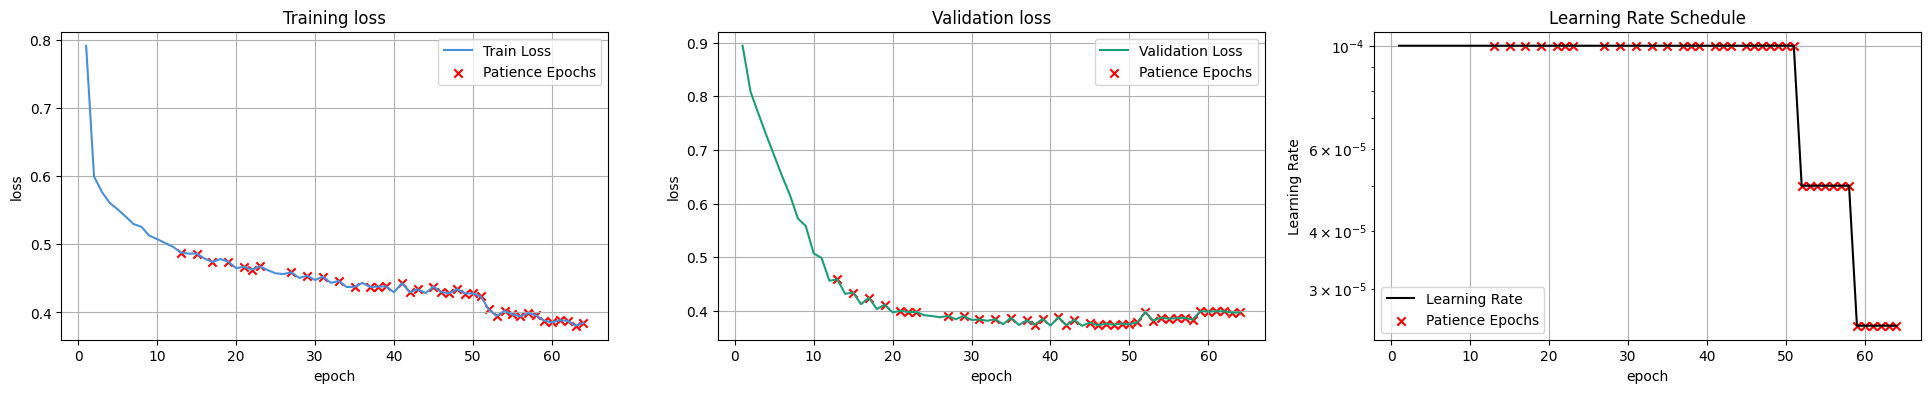

In [34]:
gatv2_1 = GATv2LSTMModel(graphdata_1, name = 'gatv2_identity_graph', verbose = 10)
gatv2_1.set_model_hparams()
gatv2_1.set_global_hparams(**global_hparams)
gatv2_1.train()
gatv2_1.forecast('test')


==        gatv2_geographical_neighbors1         ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 4, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 001 train loss: 0.7762, val loss: 0.9031 ✓ (new best)
Epoch 002 train loss: 0.5754, val loss: 0.7908 ✓ (new best)
Epoch 003 train loss: 0.5430, val loss: 0.7510 ✓ (new best)
Epoch 004 train loss: 0.5261, val loss: 0.7130 ✓ (new best)
Epoch 005 train loss: 0.5219, val loss: 0.6878 ✓ (new best)
Epoch 006 train loss: 0.5125, val loss: 0.6516 ✓ (new best)
Epoch 007 train loss: 0.5036, val loss: 0.6244 ✓ (new best)
Epoch 008 train loss: 0.4959, val loss: 0.6012 ✓ (new best)
Epoch 009 train loss: 0.4903, val loss: 0.5882 ✓ (new best)
Epoch 010 train loss: 0.4868, val loss: 0.5662 ✓ (new best)
Epoch 011 train loss: 0.4780, val loss: 0.5546 ✓ (new best)
Epoch 012 train loss: 0.4764, val loss: 0.5363 ✓ (new best)
Epoch 013 train loss: 0.4749, val loss: 0.5163 ✓ (new best)
Epoch 014 train loss: 0.47

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:254: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3521
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 197.30it/s]

Test loss: 0.5811
forecasted ✓


GATv2LSTMModel(name='gatv2_geographical_neighbors1')

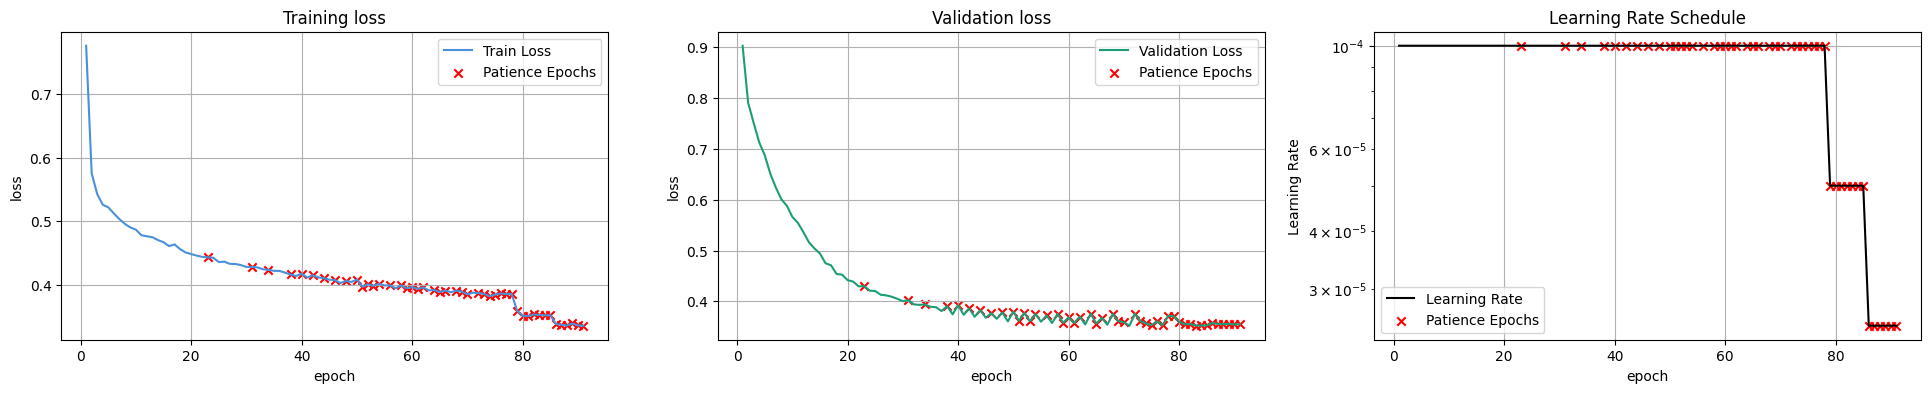

In [35]:
gatv2_2 = GATv2LSTMModel(graphdata_2, name = 'gatv2_geographical_neighbors1', verbose = 10)
gatv2_2.set_model_hparams()
gatv2_2.set_global_hparams(**global_hparams)
gatv2_2.train()
gatv2_2.forecast('test')


==                gatv2_commuer1                ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 4, 1), y=(400, 1), edge_index=(2, 3905), edge_weight=(3905,))
Epoch 001 train loss: 0.8057, val loss: 0.9353 ✓ (new best)
Epoch 002 train loss: 0.5971, val loss: 0.8119 ✓ (new best)
Epoch 003 train loss: 0.5613, val loss: 0.7716 ✓ (new best)
Epoch 004 train loss: 0.5476, val loss: 0.7369 ✓ (new best)
Epoch 005 train loss: 0.5398, val loss: 0.7058 ✓ (new best)
Epoch 006 train loss: 0.5333, val loss: 0.6811 ✓ (new best)
Epoch 007 train loss: 0.5246, val loss: 0.6546 ✓ (new best)
Epoch 008 train loss: 0.5240, val loss: 0.6390 ✓ (new best)
Epoch 009 train loss: 0.5142, val loss: 0.6174 ✓ (new best)
Epoch 010 train loss: 0.5074, val loss: 0.6056 ✓ (new best)
Epoch 011 train loss: 0.5040, val loss: 0.5898 ✓ (new best)
Epoch 012 train loss: 0.4973, val loss: 0.5828 ✓ (new best)
Epoch 013 train loss: 0.4970, val loss: 0.5708 ✓ (new best)
Epoch 014 train loss: 0.49

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:254: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3482
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 216.98it/s]

Test loss: 0.5517
forecasted ✓


GATv2LSTMModel(name='gatv2_commuer1')

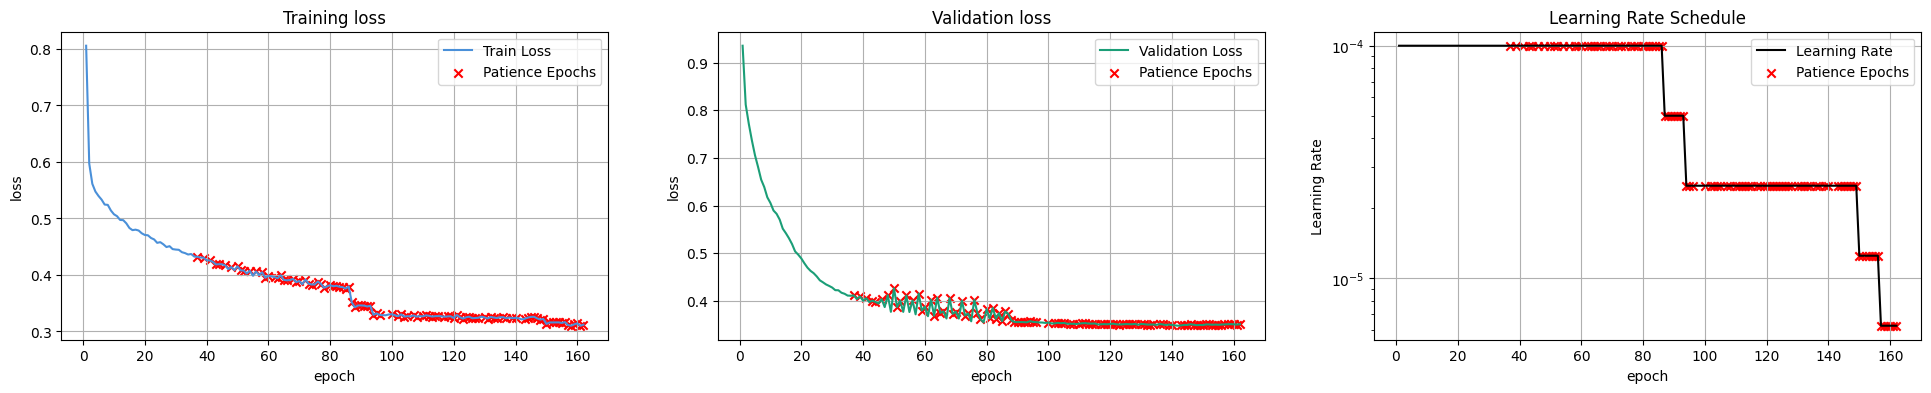

In [36]:
gatv2_3 = GATv2LSTMModel(graphdata_4, name = 'gatv2_commuer1', verbose = 10)
gatv2_3.set_model_hparams()
gatv2_3.set_global_hparams(**global_hparams)
gatv2_3.train()
gatv2_3.forecast('test')

computing metrics:   0%|                                                                                                                                                                | 0/8 [00:00<?, ?it/s]

computing metrics:  88%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                   | 7/8 [00:05<00:00,  1.17it/s]/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/metrics.py:58: RuntimeWarning: divide by zero encountered in scalar divide
  r2=  float(1 - ss_res/ ss_tot)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/metrics.py:58: RuntimeWarning: divide by zero encountered in scalar divide
  r2=  float(1 - ss_res/ ss_tot)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/metrics.py:58: RuntimeWarning: divide by zero encountered in scalar divide
  r2=  float(1 - ss_res/ ss_tot)
computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:06<00:00,  1.25it/s]
/scratch/de-schrijvers/projects/infectious_disease_gn

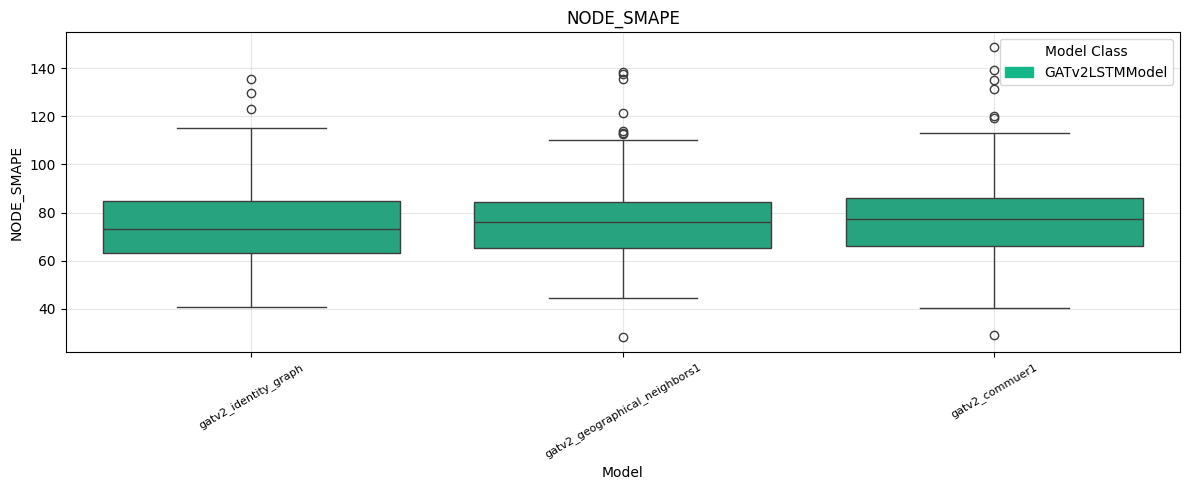

In [37]:
from src.evaluation import Evaluator

evaluation_experiment_gcn   = Evaluator([gatv2_1, gatv2_2, gatv2_3]).add_evaluation()
f_merged_raw_gcn            = evaluation_experiment_gcn.plotter.plot_metric_compilation(subfig_size = (8,4), metrics = ['rmse','pearson_corr','spearman_corr','ccc'], plot_types = ['box','box','box','box']);



evaluation_experiment_gcn.plotter.plot_single_metric('node_smape',0, plot_type='box').show()

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplott

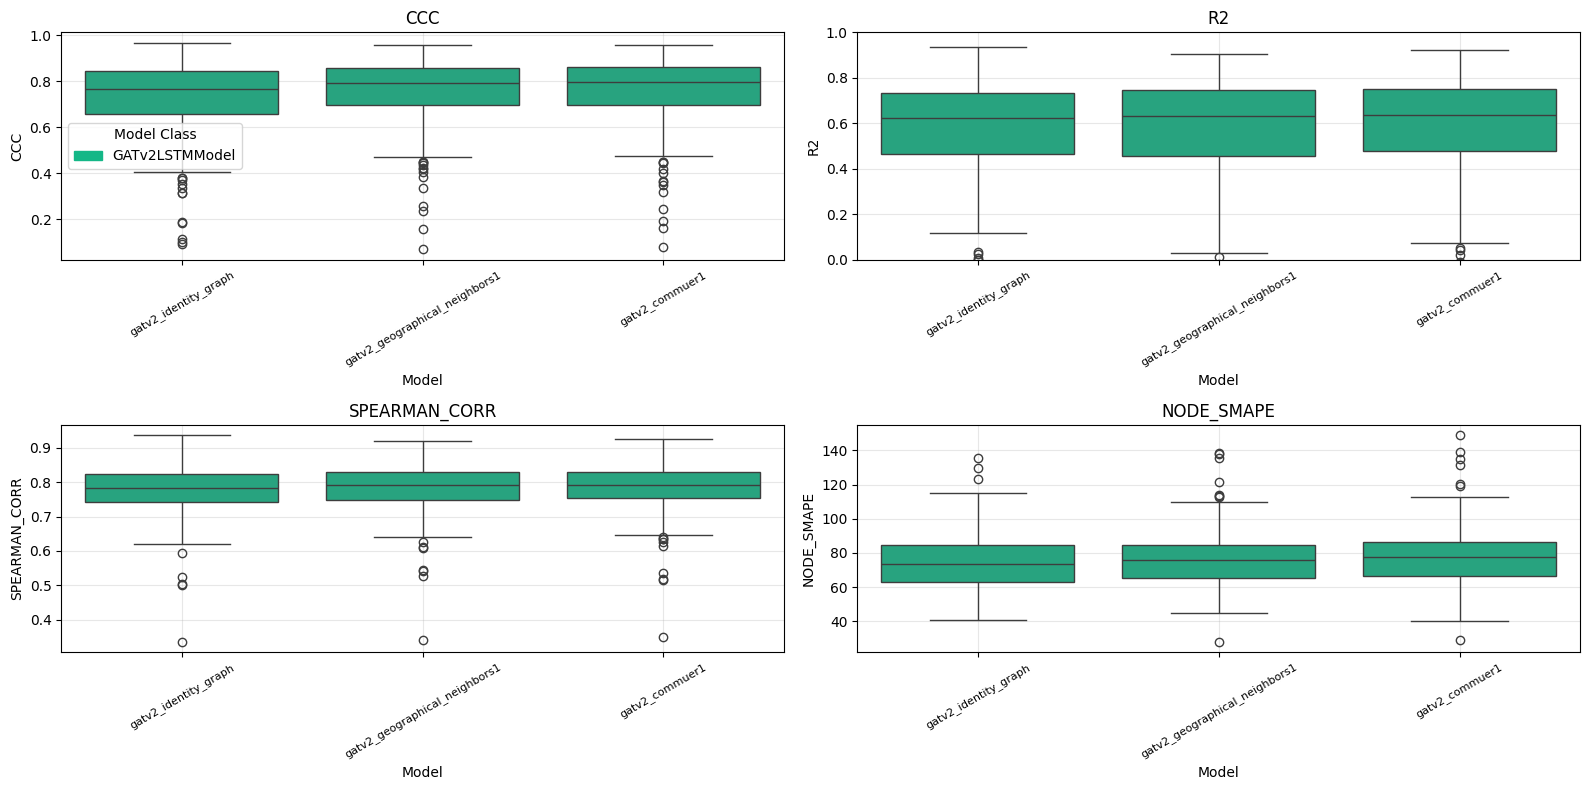

In [47]:
f_merged_raw_gcn            = evaluation_experiment_gcn.plotter.plot_metric_compilation(subfig_size = (8,4), metrics = ['ccc','r2','spearman_corr','node_smape'], plot_types = ['box','box','box','box']);

f_merged_raw_gcn = f_merged_raw_gcn.layout.set_ylim([0,1],ax = 1)
f_merged_raw_gcn.show()

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


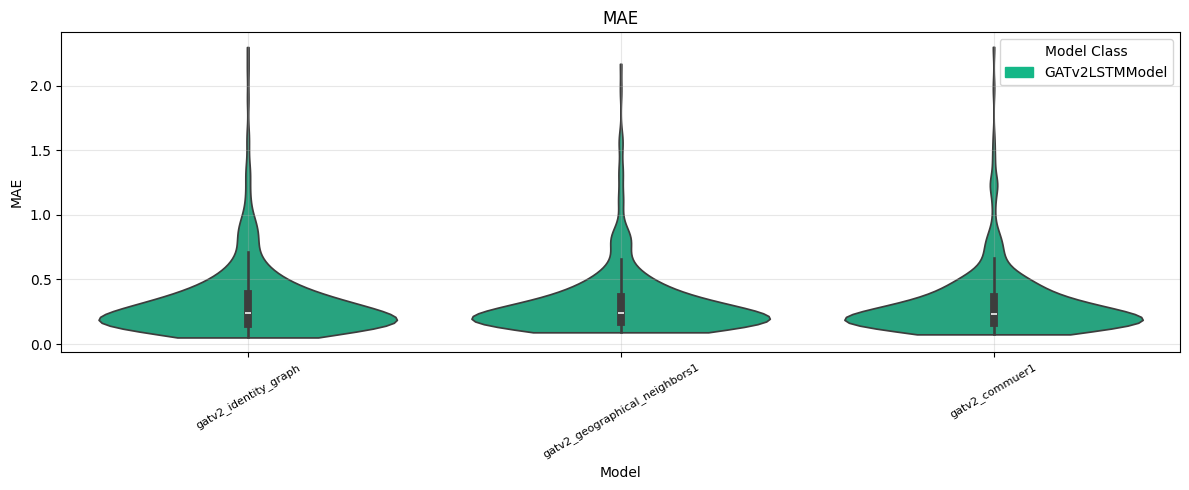

In [39]:
evaluation_experiment_gcn.plotter.plot_single_metric('mae',0, plot_type='violin').show()

In [40]:
import numpy as np
def spatial_autocorrelation_of_errors(predictions_df, edge_index):
    """
    Moran's I for prediction errors
    Checks if errors are spatially clustered
    """
    import pandas as pd
    
    # Calculate errors per node
    errors_by_node = predictions_df.groupby('node')['pred'].apply(
        lambda x: (x - predictions_df.loc[x.index, 'target']).abs().mean()
    )
    
    # Moran's I calculation
    n = len(errors_by_node)
    y = errors_by_node.values
    y_mean = y.mean()
    
    # Build adjacency matrix from edge_index
    W = np.zeros((n, n))
    for i in range(edge_index.shape[1]):
        src, dst = edge_index[:, i]
        W[src, dst] = 1
    
    # Row normalize
    W = W / W.sum(axis=1, keepdims=True)
    
    # Moran's I
    numerator = np.sum(W * np.outer(y - y_mean, y - y_mean))
    denominator = np.sum((y - y_mean) ** 2)
    morans_i = (n / W.sum()) * (numerator / denominator)
    
    return morans_i

# Use it
model = gatv2_2

predictions = model.predictions.get_preds('test').get_original(0)
morans_i = spatial_autocorrelation_of_errors(
    predictions, 
    model.dataloadermanager.graph.edge_index
)
print(f"Moran's I for errors: {morans_i:.3f}")
print("(Positive = errors clustered, 0 = random, Negative = dispersed)")

Moran's I for errors: 0.691
(Positive = errors clustered, 0 = random, Negative = dispersed)


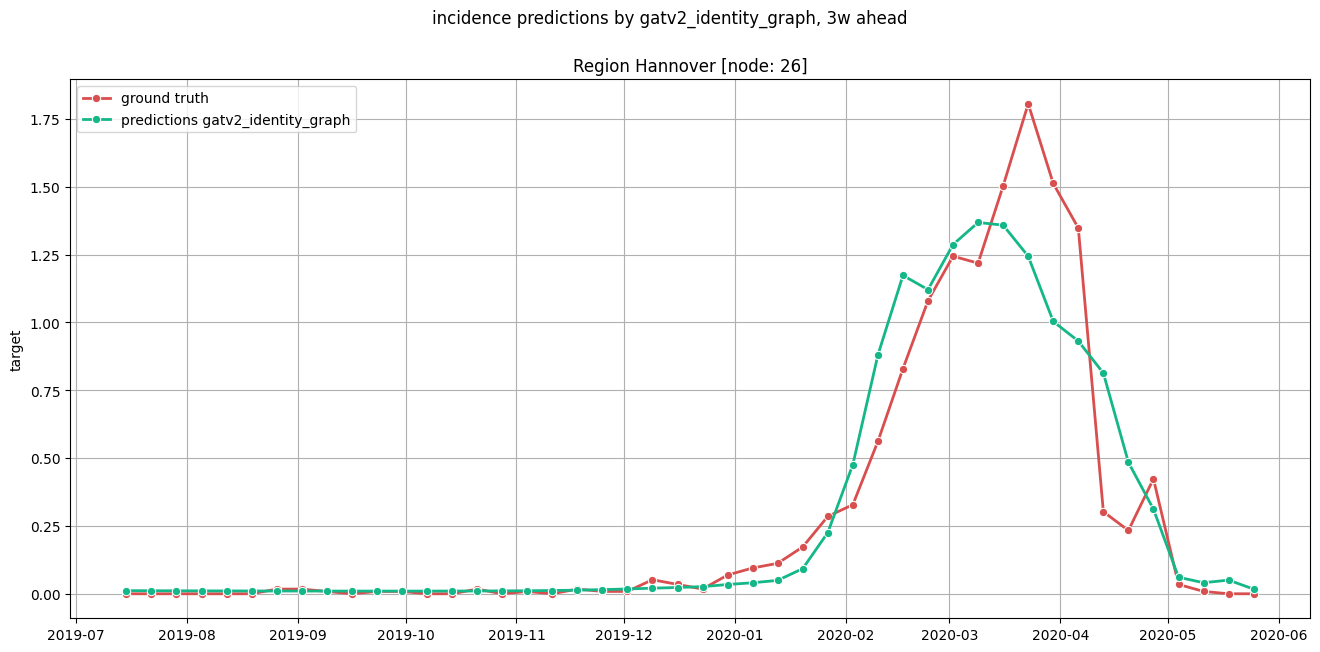

In [45]:
gatv2_1.show_forecasts(26).show()

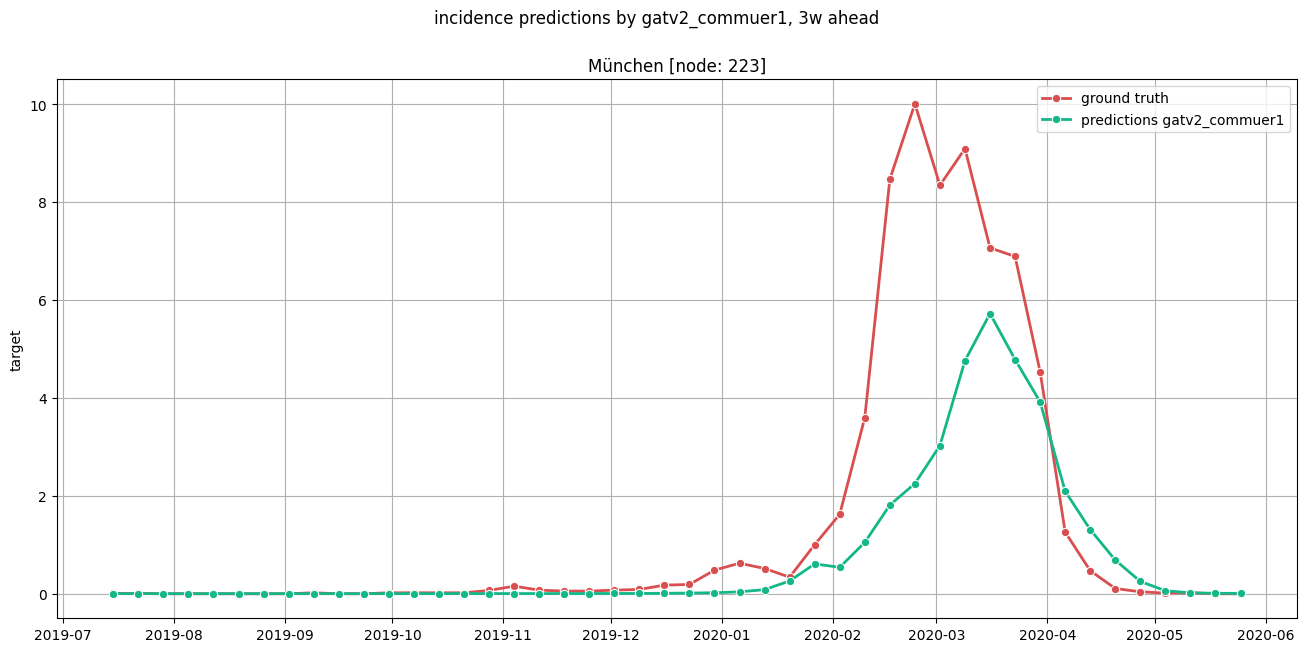

In [52]:
gatv2_3.show_forecasts(223).show()

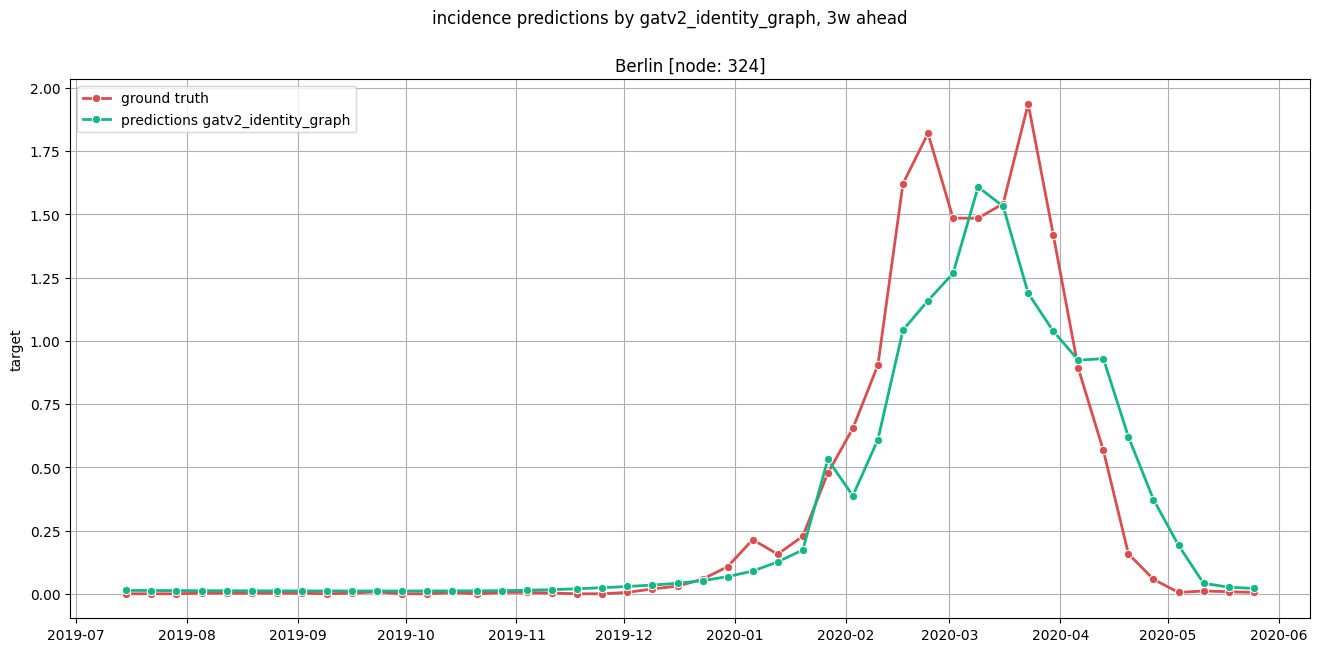

In [43]:
gatv2_1.show_forecasts(324).show()